In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import joblib
import pandas as pd
import seaborn as sns
from   sklearn.datasets import fetch_openml
from   sklearn.pipeline import Pipeline
import optuna
import shap
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.model_selection import learning_curve
from sklearn.metrics import make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, classification_report

np.random.seed(42)

In [3]:
# Hämta MNIST-datasetet
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)

# Definiera X och y
X = mnist["data"]
y = mnist["target"].astype(np.uint8)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Spara data och mål som NumPy-filer
np.save("X_mnist.npy",X)
np.save("y_mnist.npy", y)

# Kontrollera om några bilder är tomma (alla pixelvärden = 0)
empty_indices = np.where(X.sum(axis=1) == 0)[0]

# Skriv ut information om de tomma bilderna
print(f"Antal tomma bilder: {len(empty_indices)}")
print(f"Index för tomma bilder: {empty_indices}")

X shape: (70000, 784)
y shape: (70000,)
Antal tomma bilder: 0
Index för tomma bilder: []


In [ ]:
# Fördela data i tränings, valdiation och testset

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.4285, random_state=42)

# Ange antalet träningsobservationer som ska vara 25 000
train_size = 25000

# Fördela tränings- och valideringsdatan så att valideringsdatan utgör resterande del
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, train_size=train_size, random_state=42)

# Kontrollera storleken på tränings- och valideringsdatan
print(f'Train data shape: {X_train.shape}, {y_train.shape}')
print(f'Validation data shape: {X_val.shape}, {y_val.shape}')
print(f'Test data shape: {X_test.shape}, {y_test.shape}')

Train data shape: (25000, 784), (25000,)
Validation data shape: (15005, 784), (15005,)
Test data shape: (29995, 784), (29995,)


In [5]:
knn = Pipeline([
    ('scaler', StandardScaler()), 
    ('model', KNeighborsClassifier(n_jobs=-1))
])

knn = knn.fit(X_train, y_train)
score = knn.score(X_val, y_val)
joblib.dump(knn,'knn_trained.pkl')
print('Modellen är tränad, och sparad.')
print("KNeighborsClassifier", score)

Modellen är tränad, och sparad.
KNeighborsClassifier 0.935021659446851


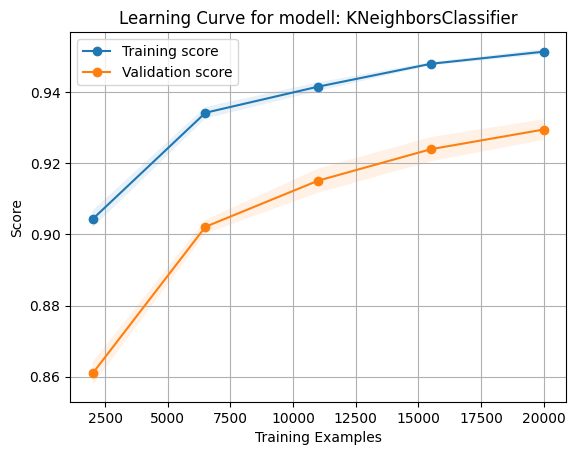

In [8]:
# Ladda den sparade pipelinen med modellen
knn = joblib.load('knn_trained.pkl')

# Funktion för att plotta inlärningskurva
def plot_learning_curve(estimator, title, X, y):
    train_sizes, train_scores, val_scores = learning_curve(estimator, X, y, cv=5, n_jobs=-1)
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    plt.plot(train_sizes, train_mean, 'o-', label='Training score')
    plt.plot(train_sizes, val_mean, 'o-', label='Validation score')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1)
    plt.title(title)
    plt.xlabel('Training Examples')
    plt.ylabel('Score')
    plt.legend()
    plt.grid()
    plt.show()

# Plotta inlärningskurva för den laddade pipelinen med modellen
plot_learning_curve(knn, 'Learning Curve for modell: KNeighborsClassifier', X_train, y_train)

In [12]:
knn = joblib.load('knn_trained.pkl') 
y_pred = knn.predict(X_test)
print("Classification Report för KNeighborsClassifier")
print(classification_report(y_test, y_pred))

Classification Report för KNeighborsClassifier
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      2966
           1       0.93      0.99      0.96      3380
           2       0.94      0.92      0.93      3004
           3       0.91      0.93      0.92      3026
           4       0.94      0.92      0.93      2844
           5       0.92      0.90      0.91      2699
           6       0.95      0.97      0.96      2975
           7       0.93      0.92      0.92      3185
           8       0.97      0.86      0.91      2887
           9       0.89      0.91      0.90      3029

    accuracy                           0.93     29995
   macro avg       0.93      0.93      0.93     29995
weighted avg       0.93      0.93      0.93     29995



In [14]:
# Ladda den sparade modellen
knn= joblib.load('knn_trained.pkl')

# Definiera scorer
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# Beräkna cross-validation scores
cv_results = cross_validate(knn, X_train, y_train, cv=5, scoring=scoring)

# Skapa en lista med resultaten
log_reg_results = []
for fold in range(5):
    log_reg_results.append({
        'Fold': fold,
        'Accuracy': cv_results['test_accuracy'][fold],
        'Precision': cv_results['test_precision'][fold],
        'Recall': cv_results['test_recall'][fold],
        'F1-score': cv_results['test_f1'][fold]
    })

# Konvertera listan till en DataFrame
log_reg_results = pd.DataFrame(log_reg_results)

# Spara DataFrame med joblib
joblib.dump(log_reg_results, 'cross_validation_results.pkl')

# Visa DataFrame
log_reg_results

,Fold,Accuracy,Precision,Recall,F1-score
0,0,0.9276,0.927802,0.926443,0.926584
1,1,0.9296,0.930184,0.929109,0.929246
2,2,0.9250,0.926027,0.923965,0.924300
3,3,0.9326,0.932624,0.931636,0.931655
4,4,0.9324,0.932681,0.931517,0.931614


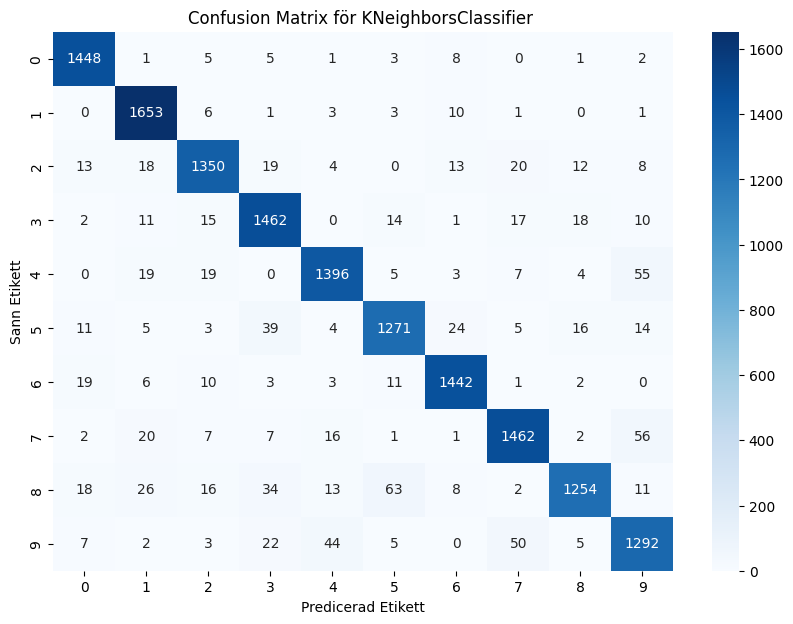

In [16]:
# Ladda tränade Logistiska regression modellen
knn = joblib.load('knn_trained.pkl')

# Gör prediktioner på testdata
y_val_pred = knn.predict(X_val)

# Skapa Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)

# Visualisera Confusion Matrix som en heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Confusion Matrix för KNeighborsClassifier ')
plt.xlabel('Predicerad Etikett')
plt.ylabel('Sann Etikett')
plt.show()

In [17]:
print("Misstag mellan 5 och 8 :", cm[5, 8])
print("Misstag mellan 8 och 5 :", cm[8, 5])
print('Största prediktionsfelet:', 63 /25000)

Misstag mellan 5 och 8 : 16
Misstag mellan 8 och 5 : 63
Största prediktionsfelet: 0.00252


Prediktioner med KNeighborsClassifier 


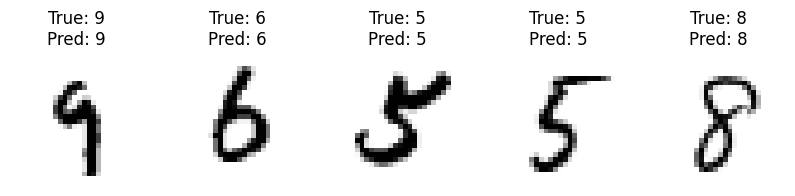

In [19]:
#laddar in tränad modell till processen
knn= joblib.load('knn_trained.pkl')

#Skapar en funktion, plot_prediction som loopar över 5 MNSIT-bilder, visar sanna etiketten, bilden, samt modellens prediktionen
def plot_predictions(images, labels, predictions, n=5):
    plt.figure(figsize=(10, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap='binary')
        plt.title(f'True: {labels[i]}\nPred: {predictions[i]}')
        plt.axis('off')
    plt.show()

# Visualiering, hur väl modellen predikterar 5 bilder från MNIST
examples = 5
X_example = X_train[:examples]
y_true_example = y_train[:examples]


# Gör prediktioner med varje tränad modell
y_pred_example = knn.predict(X_example)

print('Prediktioner med KNeighborsClassifier ')
plot_predictions(X_example, y_true_example, y_pred_example)